In [127]:

from pathlib import Path
import shutil


import matplotlib.pyplot as plt
import numpy as np

from torchvision.datasets import ImageFolder
# V1 or V2? https://docs.pytorch.org/vision/main/transforms.html#v1-or-v2-which-one-should-i-use
import torchvision.transforms.v2 as T
import torch
from torch.utils.data import DataLoader, random_split
import torchmetrics

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

import kagglehub

# Download latest version
path = kagglehub.dataset_download("datamunge/sign-language-mnist")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/datamunge/sign-language-mnist


In [128]:

torch.manual_seed(12345)

train_df = pd.read_csv("/kaggle/input/datasets/datamunge/sign-language-mnist/sign_mnist_train/sign_mnist_train.csv")
val_df = pd.read_csv("/kaggle/input/datasets/datamunge/sign-language-mnist/sign_mnist_test/sign_mnist_test.csv")

train_class = train_df.pop(train_df.columns[0])
train_img = train_df.iloc[:, 0:]
print(train_img)
print(train_class)

       pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  pixel9  \
0         107     118     127     134     139     143     146     150     153   
1         155     157     156     156     156     157     156     158     158   
2         187     188     188     187     187     186     187     188     187   
3         211     211     212     212     211     210     211     210     210   
4         164     167     170     172     176     179     180     184     185   
...       ...     ...     ...     ...     ...     ...     ...     ...     ...   
27450     189     189     190     190     192     193     193     193     193   
27451     151     154     157     158     160     161     163     164     166   
27452     174     174     174     174     174     175     175     174     173   
27453     177     181     184     185     187     189     190     191     191   
27454     179     180     180     180     182     181     182     183     182   

       pixel10  ...  pixel7

In [129]:
from torchvision import transforms
transform = T.Compose([
    transforms.ToTensor() # Converts to tensor and scales to [0, 1]
])
# Apply this during dataset loading


In [130]:
train_img.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27455 entries, 0 to 27454
Columns: 784 entries, pixel1 to pixel784
dtypes: int64(784)
memory usage: 164.2 MB


In [131]:

train_img_np = train_img.to_numpy().reshape(-1, 28, 28)

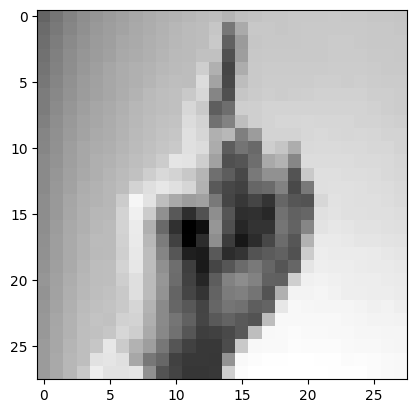

In [135]:

plt.imshow(train_img_np[0], cmap='gray')

In [133]:

# and finally, the data loaders
train_loader = DataLoader(train_set, batch_size=BATCH, shuffle=True)
val_loader = DataLoader(val_set, batch_size=BATCH)

NameError: name 'BATCH' is not defined

In [ ]:


# what classes exist?
class_names = train_val.classes
print(len(class_names),"classes")
class_names